In [67]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import matplotlib as plt
from sklearn.cluster import KMeans
from geopy.geocoders import Nominatim

In [68]:
# Download city boundaries
place = "Tampa, Florida, USA"
boundary = ox.geocode_to_gdf(place)

In [69]:
# Download the road map data
graph = ox.graph_from_place(place, network_type="drive")

# Project the graph to local UTM -> avoiding distortion
graph_proj = ox.project_graph(graph)

In [70]:
# Initialize the geolocator
geolocator = Nominatim(user_agent="tampa_logistics_app")

# Provide the address (random address at Tampa port)
address = "1101 Channelside Dr, Tampa, FL 33602"

# Get the coordinates
location = geolocator.geocode(address)

if location:
    warehouse_lat = location.latitude
    warehouse_long = location.longitude
    print(f"Latitude: {location.latitude}, Longitude: {location.longitude}")
else:
    print("Address not found!")

Latitude: 27.951531, Longitude: -82.445453


In [74]:
# Create a GDF for the warehouse
warehouse_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([warehouse_long], [warehouse_lat]), 
    crs="EPSG:4326"
).to_crs(graph_proj.graph['crs'])

# Snap the warehouse to the nearest road node too!
warehouse_node = ox.distance.nearest_nodes(graph_proj, [warehouse_long], [warehouse_lat])[0]

In [ ]:
# Generating 300 random (x,y) points in inside Tampa boundaries
min_x, min_y, max_x, max_y = boundary.total_bounds

points = []

while len(points) < 300:
    x = np.random.uniform(min_x, max_x)
    y = np.random.uniform(min_y, max_y)
    p = gpd.points_from_xy([x],[y])[0]

    if p.within(boundary.geometry.iloc[0]):
        points.append(p)


<Axes: >

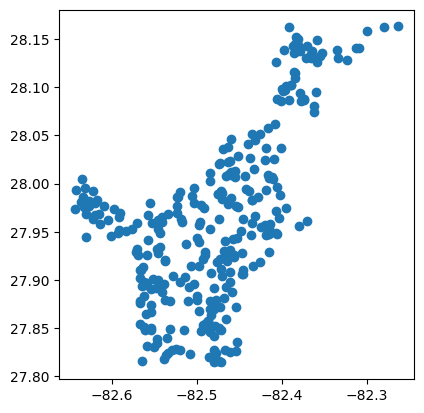

In [60]:
# Creating a GDF 
delivery_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
delivery_gdf.plot()

In [ ]:
# Save raw generated data
delivery_gdf.to_file("../data/raw/delivery_points_raw.geojson"
                     , driver="GeoJSON")
# Save the road network
ox.save_graphml(graph_proj, filepath="../data/processed/tampa_road_network.graphml")

In [25]:
# converting to meters for accurate distance math
delivery_gdf_proj = delivery_gdf.to_crs(graph_proj.graph['crs'])

# finding nearest roads Ids (nodes)
nodes = ox.distance.nearest_nodes(
    graph_proj,
    delivery_gdf_proj.geometry.x,
    delivery_gdf_proj.geometry.y)

In [ ]:
# create the snapped points IDs -> POINT
snapped_points = [gpd.points_from_xy([graph_proj.nodes[n]['x']],
                                     [graph_proj.nodes[n]['y']])[0]
                for n in nodes]
# create a new GDF for the final locations
snapped_gdf = gpd.GeoDataFrame(geometry=snapped_points, crs=graph_proj.graph['crs'])

In [ ]:
# Save processed / cleaned data (road snapped delivery locations)
snapped_gdf.to_file("../data/processed/delivery_points_snapped.gpkg", driver="GPKG")

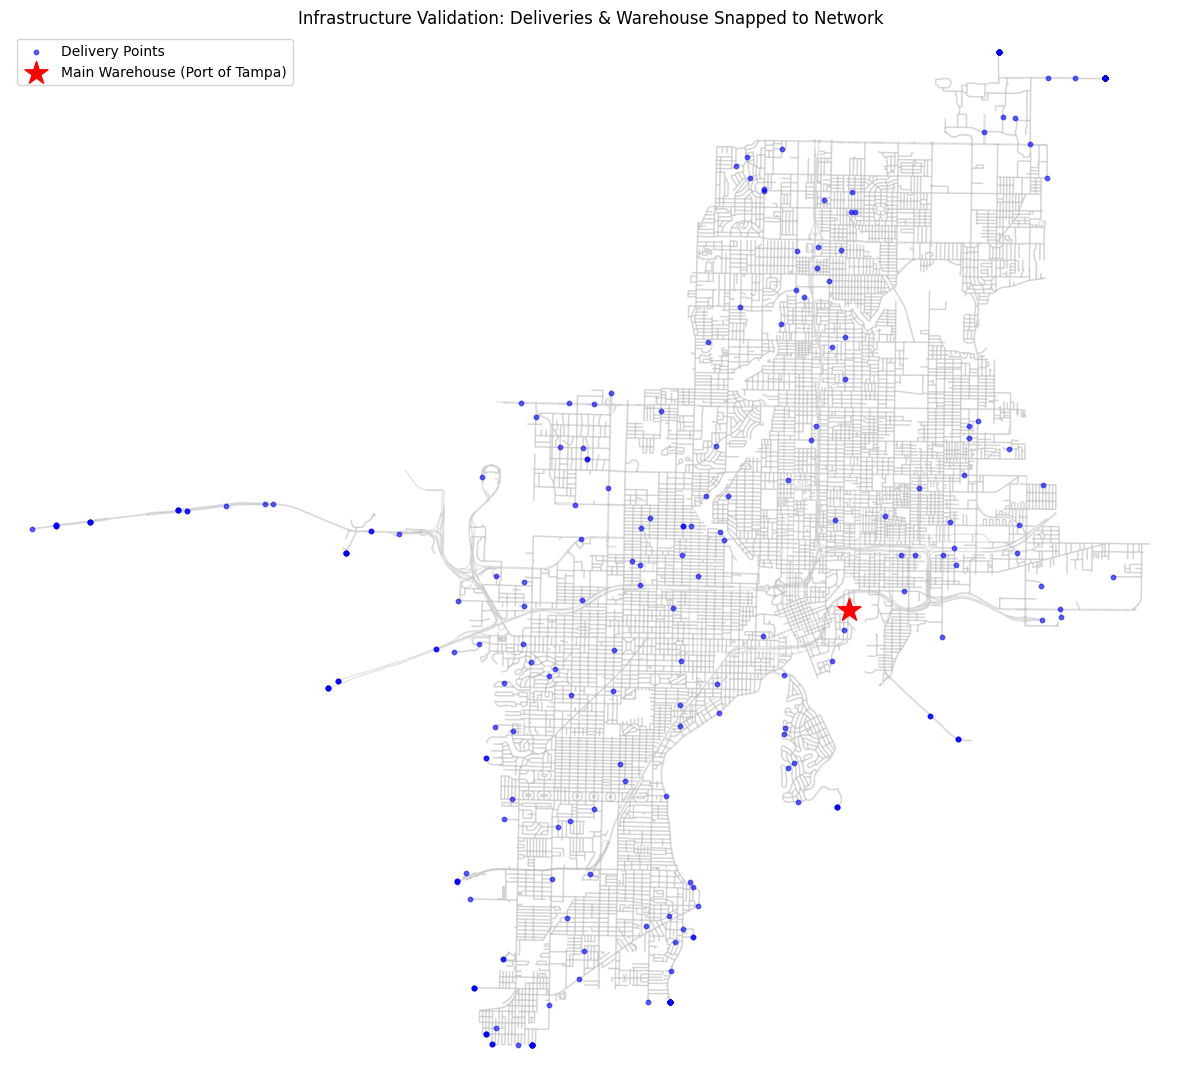

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# 1. Plot the road network
ox.plot_graph(graph_proj, ax=ax, show=False, close=False, edge_color='#bcbcbc', edge_alpha=0.4, node_size=0)

# 2. Plot the 300 delivery points (Blue)
snapped_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='Delivery Points')

# 3. Plot the Warehouse (Red Star)
# We pull the coordinates directly from the warehouse_gdf we created
warehouse_gdf.plot(ax=ax, color='red', marker='*', markersize=300, label='Main Warehouse (Port of Tampa)')

plt.legend()
plt.title("Infrastructure Validation: Deliveries & Warehouse Snapped to Network")

# save a copy
plt.savefig('../reports/figures/infrastructure_validation.png', dpi=300, bbox_inches='tight')
plt.show()